In [57]:
import os
import re
import time
import numpy as np
import pandas as pd
import pickle
import base64
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from openai import OpenAI, RateLimitError
print('Imports done')

Imports done


In [58]:
import os

API_KEY = os.environ.get('TYPHOON_API_KEY', '')
if not API_KEY:
    raise ValueError('Please set the TYPHOON_API_KEY environment variable')
print('API key loaded')

API key loaded


In [59]:
def normalize(text):
    return re.sub(r'\s+', ' ', text.lower())

In [60]:
MONTHS = (
    'jan|january|feb|february|mar|march|apr|april|may|'
    'jun|june|jul|july|aug|august|sep|september|'
    'oct|october|nov|november|dec|december'
)

In [61]:
client = OpenAI(
    api_key=API_KEY,
    base_url='https://api.opentyphoon.ai/v1'
)

def extract_text(image_path):
    with open(image_path, 'rb') as f:
        image_data = base64.b64encode(f.read()).decode('utf-8')

    ext = image_path.split('.')[-1].lower()
    mime = 'image/jpeg' if ext in ['jpg', 'jpeg'] else 'image/png'

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model='typhoon-ocr',
                messages=[{
                    'role': 'user',
                    'content': [
                        {
                            'type': 'image_url',
                            'image_url': {
                                'url': f'data:{mime};base64,{image_data}'
                            }
                        },
                        {
                            'type': 'text',
                            'text': 'Extract all text from this receipt image.'
                        }
                    ]
                }],
                max_tokens=2000
            )
            return response.choices[0].message.content
        except RateLimitError:
            print(f'Rate limit hit, waiting 60s... (attempt {attempt+1})')
            time.sleep(60)
    return ''

In [62]:
def detect_store_name(text):
    keywords = ['co.', 'ltd', 'shop', 'store', 'hotel', 'company',
                'center', 'centre', 'supply', 'service', 'bakery',
                'cafe', 'restaurant', 'terrace', 'flowers', 'science',
                'office', 'design', 'connect', 'clean', 'resort',
                'handicraft', 'boutique', 'studies', 'book', 'van']
    t = normalize(text)
    for kw in keywords:
        if kw in t:
            return 1
    return 0

In [63]:
def detect_store_address(text):
    MFU_KEYWORDS = ['333 moo 1', 'thasud', 'mae fah luang',
                    'thasud subdistrict', '57100, thailand']
    
    address_keywords = [
        'road', 'rd.', 'rd,', 'street', 'st.',
        'moo', 'ban du', 'rob wiang', 'jetyod',
        'kwae wai', 'phahonyothin', 'san khong',
        'sri wiang', 'super highway', 'wiang,',
        'muang,', 'chiang rai 57', 'ถนน', 'แขวง',
        'เขต', 'กรุงเทพ', 'หมู่'
    ]
    
    def is_mfu_line(line):
        lower = line.lower()
        return any(kw in lower for kw in MFU_KEYWORDS)
    
    def looks_like_address(line):
        lower = line.lower().strip()
        if any(kw in lower for kw in address_keywords):
            return True
        if re.search(r'^\d+[\/\s]\d*\s+[A-Za-z]', line.strip()):
            return True
        if re.search(r'\b\d{5}\b', line) and len(line) < 60:
            return True
        return False
    
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    total = len(lines)
    
    for line in lines[:int(total * 0.35)]:
        if not is_mfu_line(line) and looks_like_address(line):
            return 1
    
    for line in lines[int(total * 0.75):]:
        if not is_mfu_line(line) and looks_like_address(line):
            return 1
    
    return 0

In [64]:
def detect_store_tax_id(text):
    MFU_TAX_ID = '0994000165178'
    matches = re.findall(r'tax\s*id[:\s]+[\d\-]{10,}', text, re.IGNORECASE)
    for m in matches:
        nums = re.sub(r'[^\d]', '', m)
        clean = nums[-13:] if len(nums) >= 13 else nums
        if clean != MFU_TAX_ID and len(clean) >= 10:
            return 1
    all_ids = re.findall(r'\b\d{13}\b', text)
    for tid in all_ids:
        if tid != MFU_TAX_ID:
            return 1
    return 0

In [65]:
def detect_date(text):
    patterns = [
        r'\b\d{1,2}[\s]+[A-Za-z]{3,}[\s]+\d{4}\b',
        r'\b[A-Za-z]{3,}[\s]+\d{1,2},?[\s]+\d{4}\b',
        r'\b\d{1,2}[\/\-]\d{1,2}[\/\-]\d{2,4}\b',
        r'\bdate[:\s]+.{1,30}\d{4}\b',
    ]
    for p in patterns:
        if re.search(p, text, re.IGNORECASE):
            return 1
    return 0

In [66]:
def detect_amount(text):
    if re.search(r'grand\s*total[\s:]*[\d,]+\.\d{2}', text, re.IGNORECASE):
        return 1
    matches = list(re.finditer(
        r'(?<![a-z])total[\s:\*]*([\d,]+\.\d{2})', text, re.IGNORECASE))
    for m in matches:
        before = text[max(0, m.start()-20):m.start()].lower()
        if 'sub' not in before and 'partial' not in before:
            return 1
    return 0

In [67]:
def detect_amount_in_words(text):
    t = normalize(text)
    if re.search(r'baht\s+only', t):
        return 1
    if re.search(r'baht\s+and\s+\w+\s+satang', t):
        return 1
    if re.search(r'amount[\s:]*\(?[a-z\s\-,]+baht', t):
        return 1
    return 0

In [68]:
def detect_signature(text):
    keywords = ['signature', 'signed by', 'approved by',
                'received by', 'cashier', 'manager', 'finance staff']
    t = normalize(text)
    for kw in keywords:
        if kw in t:
            return 1
    return 0

In [69]:
def detect_mfu_name(text):
    return int('mae fah luang university' in normalize(text))

In [70]:
def detect_mfu_address(text):
    keywords = ['333 moo 1', 'thasud', 'muang', 'chiang rai', '57100']
    t = normalize(text)
    return int(all(kw in t for kw in keywords))

In [71]:
def detect_mfu_tax_id(text):
    return int('0994000165178' in text)

In [72]:
gt = pd.read_csv('ground_truth.csv')
print('Ground truth loaded:', gt.shape)
print(gt.head())

Ground truth loaded: (20, 12)
  filename  has_store_name  has_store_address  has_store_tax_id  has_date  \
0   U1.jpg               1                  1                 1         1   
1   U2.jpg               0                  0                 1         1   
2   U3.jpg               1                  1                 1         0   
3   U4.jpg               1                  1                 1         0   
4   U5.jpg               0                  0                 0         1   

   has_amount  has_amount_words  has_signature  has_mfu_name  has_mfu_address  \
0           1                 0              0             1                1   
1           1                 1              1             1                1   
2           1                 1              1             1                1   
3           1                 1              1             1                1   
4           1                 0              1             1                1   

   has_mfu_tax_id  l

In [73]:
FIELDS = [
    'has_store_name', 'has_store_address', 'has_store_tax_id',
    'has_date', 'has_amount', 'has_amount_words',
    'has_signature', 'has_mfu_name', 'has_mfu_address', 'has_mfu_tax_id'
]

def build_dataset(folder, gt_df):
    rows = []
    for img in sorted(os.listdir(folder)):
        if not img.lower().endswith(('.jpg', '.png', '.jpeg')):
            continue
        path = os.path.join(folder, img)
        print(f'Processing: {img}')
        text = extract_text(path)
        gt_row = gt_df[gt_df['filename'] == img]
        if gt_row.empty:
            print(f'  Warning: {img} not in ground_truth.csv, skipping')
            continue
        label = 1 if gt_row.iloc[0][FIELDS].sum() == 10 else 0
        rows.append({
            'filename':          img,
            'has_store_name':    detect_store_name(text),
            'has_store_address': detect_store_address(text),
            'has_store_tax_id':  detect_store_tax_id(text),
            'has_date':          detect_date(text),
            'has_amount':        detect_amount(text),
            'has_amount_words':  detect_amount_in_words(text),
            'has_signature':     detect_signature(text),
            'has_mfu_name':      detect_mfu_name(text),
            'has_mfu_address':   detect_mfu_address(text),
            'has_mfu_tax_id':    detect_mfu_tax_id(text),
            'label':             label
        })
    return rows

raw_rows = build_dataset('data', gt)
df = pd.DataFrame(raw_rows)

df.to_csv('ocr_results.csv', index=False)
print('\nocr_results.csv saved!')
print(df)

Processing: C1.jpg
Processing: C10.jpg
Processing: C2.jpg
Processing: C3.jpg
Processing: C4.jpg
Processing: C5.jpg
Processing: C6.jpg
Processing: C7.jpg
Processing: C8.jpg
Processing: C9.jpg
Processing: U1.jpg
Processing: U10.jpg
Processing: U2.jpg
Processing: U3.jpg
Processing: U4.jpg
Processing: U5.jpg
Processing: U6.jpg
Processing: U7.jpg
Processing: U8.jpg
Processing: U9.jpg

ocr_results.csv saved!
   filename  has_store_name  has_store_address  has_store_tax_id  has_date  \
0    C1.jpg               1                  1                 1         1   
1   C10.jpg               1                  1                 1         1   
2    C2.jpg               1                  1                 1         1   
3    C3.jpg               1                  1                 1         1   
4    C4.jpg               1                  1                 1         1   
5    C5.jpg               1                  1                 0         1   
6    C6.jpg               1                  1  

In [74]:
gt_df  = pd.read_csv('ground_truth.csv')
ocr_df = pd.read_csv('ocr_results.csv')
merged = pd.merge(gt_df, ocr_df, on='filename', suffixes=('_gt', '_ocr'))

short_names = [f.replace('has_','') for f in FIELDS]

print('Per-Image Comparison: Ground Truth vs OCR Result')
print('-' * 100)
header = f"{'Filename':<12} {'':14}"
for s in short_names:
    header += f" {s[:10]:>10}"
print(header)
print('-' * 100)

for _, row in merged.iterrows():

    # Ground Truth row
    gt_row = f"{row['filename']:<12} {'Ground Truth':14}"
    for field in FIELDS:
        val = int(row[field+'_gt'])
        gt_row += f" {'1 (found)' if val else '0 (miss)':>10}"
    print(gt_row)

    # OCR Result row
    ocr_row = f"{'':12} {'OCR Result':14}"
    for field in FIELDS:
        gt_val  = int(row[field+'_gt'])
        ocr_val = int(row[field+'_ocr'])
        if ocr_val == gt_val:
            label = '1 (found)' if ocr_val else '0 (miss)'
        else:
            label = 'WRONG'
        ocr_row += f" {label:>10}"
    print(ocr_row)
    print()

print('=' * 65)
print(f"{'Field':<25} {'Ground Truth':>12} {'OCR Result':>10} {'Accuracy':>10}")
print('=' * 65)

field_accuracies = {}
for field in FIELDS:
    gt_sum  = int(merged[field+'_gt'].sum())
    ocr_sum = int(merged[field+'_ocr'].sum())
    acc = accuracy_score(merged[field+'_gt'], merged[field+'_ocr'])
    field_accuracies[field] = acc
    status = 'OK' if acc >= 0.8 else 'needs fix'
    print(f"{field:<25} {gt_sum:>12} {ocr_sum:>10} {acc*100:>9.1f}%  {status}")

overall = sum(field_accuracies.values()) / len(field_accuracies)
print('=' * 65)
print(f"{'Overall Average':<25} {'':>12} {'':>10} {overall*100:>9.1f}%")
print()
if overall >= 0.8:
    print('Accuracy >= 80% --> Ready to move to HTML!')
else:
    print('Accuracy < 80% --> Fix detect functions first')
    low = [f for f, a in field_accuracies.items() if a < 0.8]
    print(f'Fix these fields: {low}')


Per-Image Comparison: Ground Truth vs OCR Result
----------------------------------------------------------------------------------------------------
Filename                    store_name store_addr store_tax_       date     amount amount_wor  signature   mfu_name mfu_addres mfu_tax_id
----------------------------------------------------------------------------------------------------
U1.jpg       Ground Truth    1 (found)  1 (found)  1 (found)  1 (found)  1 (found)   0 (miss)   0 (miss)  1 (found)  1 (found)  1 (found)
             OCR Result      1 (found)  1 (found)  1 (found)  1 (found)  1 (found)   0 (miss)      WRONG  1 (found)  1 (found)  1 (found)

U2.jpg       Ground Truth     0 (miss)   0 (miss)  1 (found)  1 (found)  1 (found)  1 (found)  1 (found)  1 (found)  1 (found)  1 (found)
             OCR Result          WRONG   0 (miss)      WRONG  1 (found)  1 (found)  1 (found)  1 (found)  1 (found)  1 (found)  1 (found)

U3.jpg       Ground Truth    1 (found)  1 (found)  1 (fou

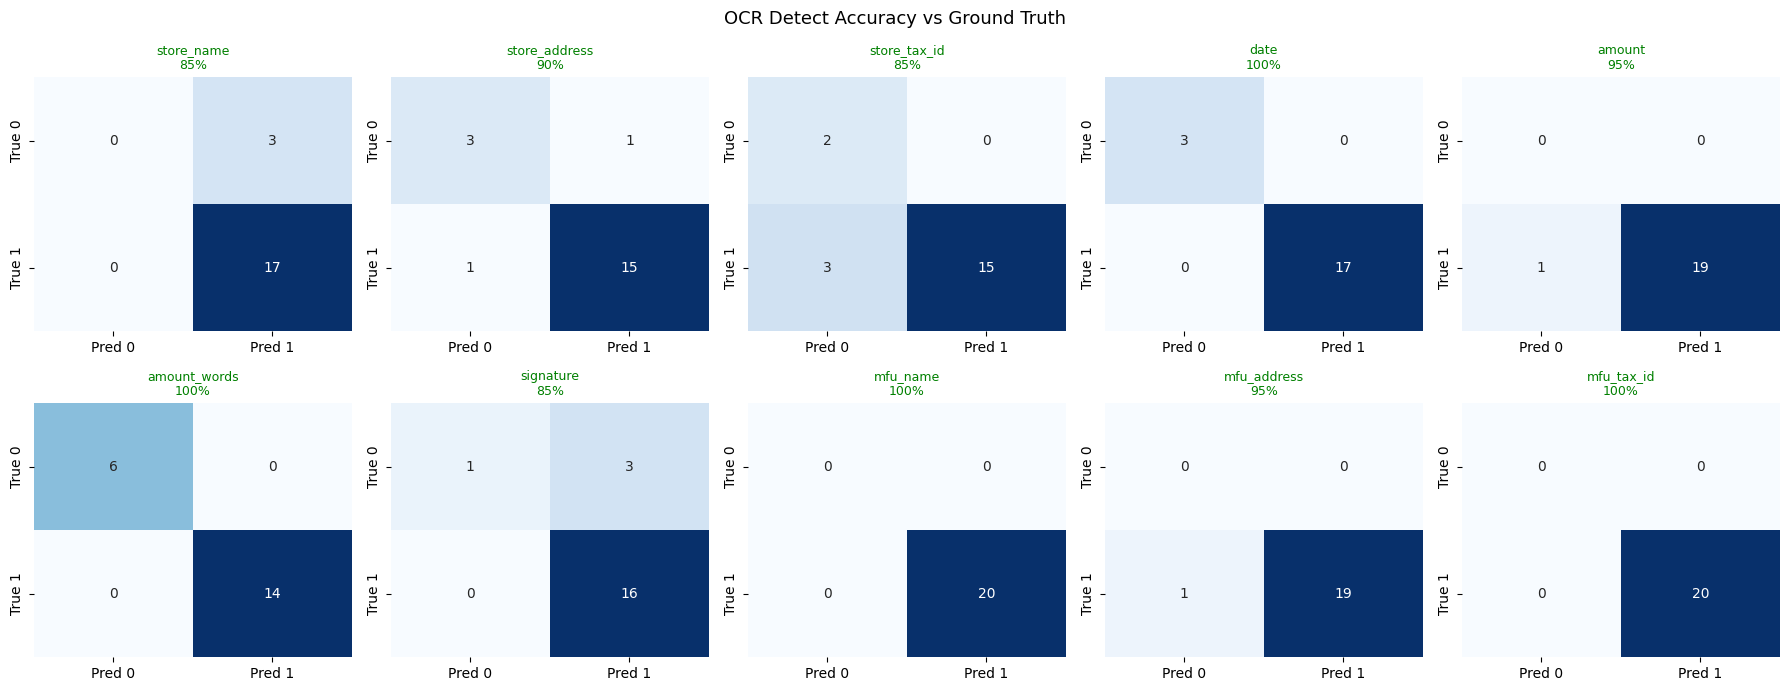

Saved → field_accuracy.png


In [75]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for idx, field in enumerate(FIELDS):
    cm = confusion_matrix(
        merged[field+'_gt'],
        merged[field+'_ocr'],
        labels=[0, 1]
    )
    acc = field_accuracies[field]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                ax=axes[idx], cbar=False)
    short = field.replace('has_', '')
    color = 'green' if acc >= 0.8 else 'red'
    axes[idx].set_title(f'{short}\n{acc*100:.0f}%', color=color, fontsize=9)

plt.suptitle('OCR Detect Accuracy vs Ground Truth', fontsize=13)
plt.tight_layout()
plt.savefig('field_accuracy.png', bbox_inches='tight')
plt.show()
print('Saved → field_accuracy.png')

In [76]:
import pandas as pd

X = df[FIELDS]
y = df['label']

print(f'Total samples: {len(X)}')
print(f'Complete (1):   {sum(y==1)}')
print(f'Incomplete (0): {sum(y==0)}')
print()

# Check if classes are linearly separable
# If complete = all 1s and incomplete = has 0s
# they are perfectly separable → any model gets 100%
complete_rows   = X[y==1]
incomplete_rows = X[y==0]

print('Complete receipts — field sums:')
print(complete_rows.sum(axis=1).value_counts())
print()
print('Incomplete receipts — field sums:')
print(incomplete_rows.sum(axis=1).value_counts())

Total samples: 20
Complete (1):   9
Incomplete (0): 11

Complete receipts — field sums:
10    9
Name: count, dtype: int64

Incomplete receipts — field sums:
9    5
7    4
8    2
Name: count, dtype: int64


In [77]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.1),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, max_depth=2),
    'Linear SVM':          SVC(kernel='linear', probability=True,
                               random_state=42, C=0.01),  # add C=0.01
}


Model                       Accuracy  Precision     Recall         F1
Logistic Regression            95.0%      90.0%     100.0%      94.7%
Decision Tree                 100.0%     100.0%     100.0%     100.0%
Linear SVM                     90.0%      81.8%     100.0%      90.0%

Best model: Decision Tree (F1 = 100.0%)


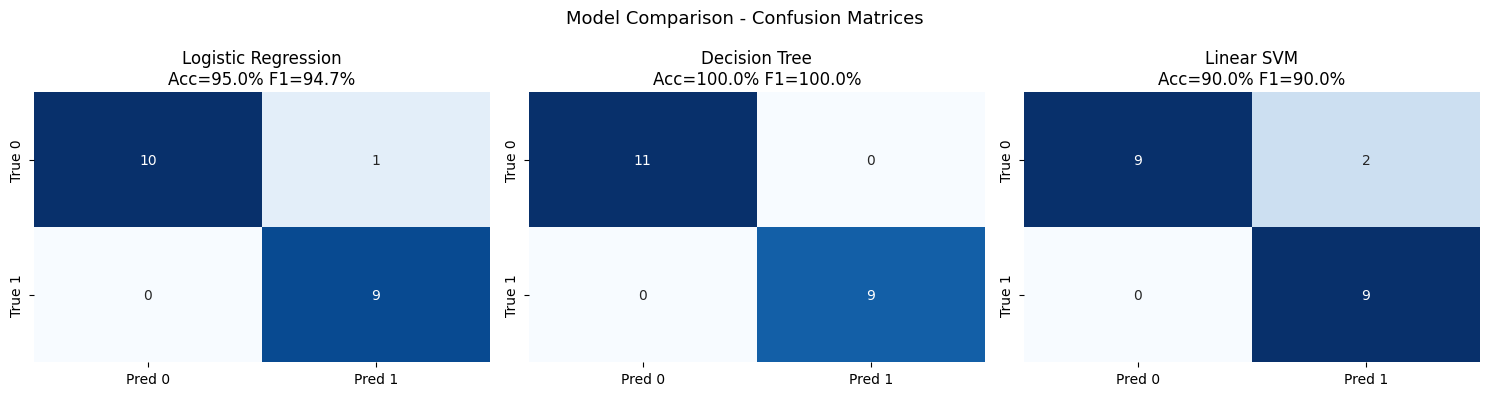

Saved --> model_comparison.png
Best model (Decision Tree) saved --> best_model.pkl


In [81]:
from sklearn.metrics import classification_report

X = df[FIELDS]
y = df['label']

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=3),    'Linear SVM':          SVC(kernel='linear', probability=True, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=' * 70)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('=' * 70)

results = {}
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred, zero_division=0)
    f1   = f1_score(y, y_pred, zero_division=0)
    results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'y_pred': y_pred}
    print(f"{name:<25} {acc*100:>9.1f}% {prec*100:>9.1f}% {rec*100:>9.1f}% {f1*100:>9.1f}%")

print('=' * 70)

# Pick best model by F1
best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\nBest model: {best_name} (F1 = {results[best_name]["f1"]*100:.1f}%)')

# Confusion matrix for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nAcc={res['acc']*100:.1f}% F1={res['f1']*100:.1f}%")
plt.suptitle('Model Comparison - Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved --> model_comparison.png')

best_model = models[best_name]
best_model.fit(X, y)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f'Best model ({best_name}) saved --> best_model.pkl')


In [79]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X, y)

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Best model> best_model.pkl')

Best model> best_model.pkl
